# Simulate data for MLR model of viral variants

In [1008]:
import pandas as pd
import numpy as np

from scipy.optimize import minimize

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

### Choose parameters

In [1127]:
def calc_growth_rates(n_variants, initial_growth_rate_range, growth_rate_increase_range):

    np.random.seed(3)

    # sample growth rates
    curr_growth_rate = np.random.uniform(*initial_growth_rate_range)
    growth_rates = [curr_growth_rate]
    for i in range(1, n_variants):
        curr_growth_rate += np.random.uniform(*growth_rate_increase_range)
        growth_rates.append(curr_growth_rate)

    growth_rates = np.array(growth_rates)
    return growth_rates

def calc_growth_rates_fixed_range(n_variants, upper_limit):

    np.random.seed(3)

    growth_rates = np.random.uniform(0, upper_limit, n_variants - 1)
    growth_rates = np.sort(growth_rates)
    growth_rates = np.concatenate([np.zeros(1), growth_rates])

    return growth_rates

def calc_log_init_freq(n_variants):

    np.random.seed(3)

    #l_init_freq = np.random.uniform(-100, 0, n_variants - 1)
    #l_init_freq = np.sort(l_init_freq)[::-1]
    #l_init_freq = np.concatenate([np.zeros(1), l_init_freq])

    l_init_freq = np.linspace(0, -100, n_variants)

    return l_init_freq

### Calculate frequencies

In [1128]:
def calculate_frequencies(n_days, alphas, growth_rates, exponential_f0 = False):
    
    if (exponential_f0):
        alphas = np.log(alphas)

    freqs = np.zeros((n_days, len(alphas)))

    for d in range(n_days):
        logits = growth_rates * d + alphas
        max_l = np.max(logits)
        freqs[d] = np.exp(logits - max_l)   #log-sum-exp trick

    freqs = freqs / np.sum(freqs, axis = 1, keepdims= True)
    
    return freqs

In [1129]:
initial_growth_rate_range = (0, 0)
growth_rate_increase_range = (0, 0.05)
variant_number = 5
days_number = 1000

#growth_rates = calc_growth_rates(variant_number, initial_growth_rate_range, growth_rate_increase_range)
growth_rates = calc_growth_rates_fixed_range(variant_number, 0.3)

#init_freq = [1, 0.03, 0.01, 0.002, 0.001]
init_freq = calc_log_init_freq(variant_number)
freq_all_viral = calculate_frequencies(days_number, init_freq, growth_rates)

### Draw samples from multinomial distribution

In [1130]:
def sample(frequencies, n_samples):
    samples = np.array([np.random.multinomial(n_samples, row) for row in frequencies])
    return samples

In [1131]:
n_samples = 1000

counts = sample(freq_all_viral, n_samples)
counts

array([[1000,    0,    0,    0,    0],
       [1000,    0,    0,    0,    0],
       [1000,    0,    0,    0,    0],
       ...,
       [   0,    0,    0,    0, 1000],
       [   0,    0,    1,    0,  999],
       [   0,    0,    0,    0, 1000]], shape=(1000, 5))

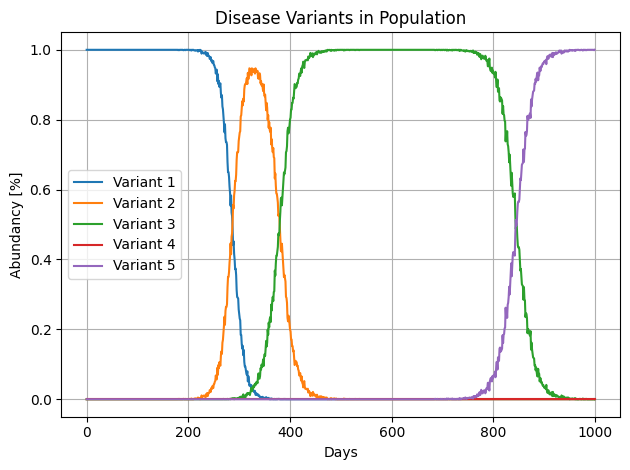

In [1132]:
# Plot each variant
def plot_variants(counts):

    for i in range(counts.shape[1]):
        plt.plot(np.arange(counts.shape[0]), counts[:, i] / n_samples, label = f'Variant {i+1}') 

    plt.xlabel("Days")
    plt.ylabel("Abundancy [%]")
    plt.title("Disease Variants in Population")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_variants(counts)


### Create count data to compare with evofr

In [1097]:
def create_count_data(n_variants, n_days, growth_rate_limit, n_samples, create_plot = True):
    growth_rates = calc_growth_rates_fixed_range(n_variants, growth_rate_limit)
    log_init_freq = calc_log_init_freq(n_variants)

    frequencies = calculate_frequencies(n_days, log_init_freq, growth_rates,)
    counts = sample(frequencies, n_samples)

    if (create_plot):
        plot_variants(counts)

    return counts


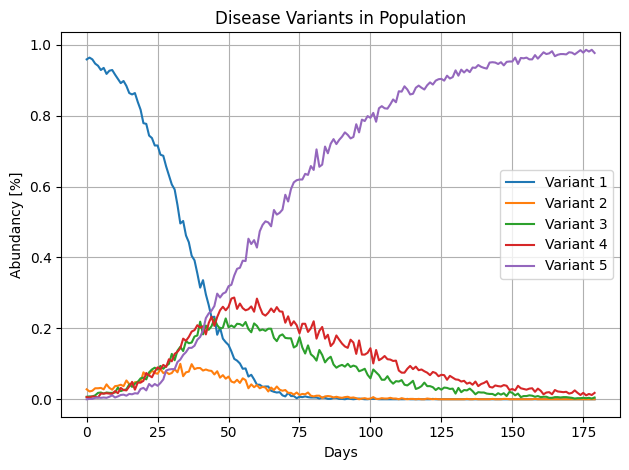

,day,variant,count
0,0,variant_0,959
1,1,variant_0,964
2,2,variant_0,959
3,3,variant_0,947
4,4,variant_0,941
...,...,...,...
895,175,variant_4,978
896,176,variant_4,986
897,177,variant_4,981
898,178,variant_4,986


In [1098]:
counts = create_count_data(5, 180, 0.2, 1000)

# Convert to DataFrame with column names as variants
counts_df = pd.DataFrame(counts, columns=[f"variant_{i}" for i in range(counts.shape[1])])
counts_df["day"] = counts_df.index

# Melt to long format
counts_df_long = counts_df.melt(id_vars="day", var_name="variant", value_name="count")
counts_df_long.to_csv('data/counts_5var_180day.csv', index = False)
counts_df_long

# Use BFGS (Broyden-Fletcher-Goldfarb-Shanno algorithm) to numerically optimize likelihood function

Likelihood function:
$$
\log \mathcal{L}(s,o) = \sum_{t=0}^{T} \left( \sum_{i=1}^{n} c_i^{(t)} \cdot \log p_i(t) \right) + \text{const.} = \sum_{t=0}^{T} \sum_{i=1}^{n} c_i^{(t)} \cdot \left[ s_i t + o_i - \log \left( \sum_{j=1}^{n} e^{s_j t + o_j} \right) \right] + \text{const.}
$$

Derivative:
$$
\frac{\partial \log \mathcal{L}(s, o)}{\partial s_i} =
\sum_{t=0}^{T} c_i^{(t)} \cdot t
- \sum_{t=0}^{T} N(t) \cdot \frac{e^{s_i t + o_i} \cdot t}{\sum_{j=1}^{n} e^{s_j t + o_j}}
$$

$$
\frac{\partial \log \mathcal{L}(s, o)}{\partial o_i} =
\sum_{t=0}^{T} c_i^{(t)} 
- \sum_{t=0}^{T} N(t) \cdot \frac{e^{s_i t + o_i}}{\sum_{j=1}^{n} e^{s_j t + o_j}}
$$

where $N(t) = \sum_{i=0}^{n} c_i^{(t)} $

To avoid not having a clear solution because all parameters are just entering the likelihood as ratios, the growth rate of the first variant is fixed to 0.

In [1015]:
def neg_log_likelihood(params, c_t):
    """
    Negative log-likelihood function as defined above. s_1 and o_1 need to be fixed to 0 to fine one optimal solution. 

    params: array od shape (2n,) where first n are s_i and last n o_i
    c_t: array of shape (T+1, n), where c_t[t, i] = c_i^(t)
    """

    T_plus_1, n = c_t.shape
    T = T_plus_1 - 1
    #s = np.concatenate([np.zeros(1), params[1:n]])
    #o = params[n:]
    s = np.insert(params[:n-1], 0, 0.0)
    o = np.insert(params[n-1:], 0, 0.0)

    ll = 0.0
    for t in range(T + 1):
        logits = s * t + o
        max_logit = np.max(logits)
        log_sum_exp = max_logit + np.log(np.sum(np.exp(logits - max_logit)))
        ll += np.dot(c_t[t], logits) - np.sum(c_t[t]) * log_sum_exp
    return -ll  # we minimize the negative log-likelihood


def grad_neg_log_likelihood(params, c_t):
    """
    Gradient of the negative log-likelihood with respect to s and o.
    """

    T_plus_1, n = c_t.shape
    T = T_plus_1 - 1
    s = params[:n]
    #s = np.concatenate([np.zeros(1), params[1:n]])
    #o = params[n:]
    s = np.insert(params[:n-1], 0, 0.0)
    o = np.insert(params[n-1:], 0, 0.0)

    grad_s = np.zeros(n)
    grad_o = np.zeros(n)

    for t in range(T + 1):
        logits = s * t + o
        max_l = np.max(logits)

        shifted_exp_logits = np.exp(logits - max_l)
        Z = np.sum(shifted_exp_logits)
        probs = shifted_exp_logits / Z

        N_t = np.sum(c_t[t])

        grad_t = c_t[t] - N_t * probs   # one time step
        grad_s += grad_t * t
        grad_o += grad_t

    return -np.concatenate([grad_s[1:], grad_o[1:]])  # gradient of negative log-likelihood excluding s_1

In [1016]:
initial_params = np.concatenate([np.repeat(0.1, 4), np.repeat(-5, 4)])
#initial_params = np.concatenate([np.linspace(0,0.1,5), np.linspace(-5, -8, 5)]) # choose better initial params
#initial_params = np.concatenate([growth_rates, [0.1, 0.001, 0.003, 0.0002, 0.0001]])

def calculate_viral_composition(initial_params, counts):
    
    result = minimize(fun = neg_log_likelihood, x0 = initial_params, args=(counts,), method = 'BFGS', jac = grad_neg_log_likelihood)
    result.x = np.insert(result.x, 0, 0.0)
    result.x = np.insert(result.x, counts.shape[1], 0.0)

    T = counts.shape[0]
    n = len(result.x) // 2
    growth_r = result.x[:n]
    log_initial_freq = result.x[n:]
    composition_estimate = np.zeros(counts.shape)

    for t in range(T):
        logits = growth_r * t + log_initial_freq
        max_l = np.max(logits)
        exp_growth = np.exp(logits - max_l)
        composition_estimate[t] = exp_growth / np.sum(exp_growth)

    return result, composition_estimate

result, composition_estimate = calculate_viral_composition(initial_params, counts)


In [1017]:
def plot_viral_composition(colors_counts, colors_line, counts, composition_estimate):
    for i in range(counts.shape[1]):
        plt.scatter(np.arange(counts.shape[0]), counts[:, i] / n_samples, color = colors_counts[i], s= 10, alpha = 0.7, label = f'Variant {i+1}')
        plt.plot(np.arange(composition_estimate.shape[0]), composition_estimate[:, i], color = colors_line[i])

    plt.xlabel("Days")
    plt.ylabel("Abundancy [%]")
    plt.title("Disease Variants in Population")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_viral_composition_2(counts, composition_estimate):
    for i in range(counts.shape[1]):
        plt.scatter(np.arange(counts.shape[0]), counts[:, i] / n_samples, s= 10, alpha = 0.4, label = f'Variant {i+1}')
        plt.plot(np.arange(composition_estimate.shape[0]), composition_estimate[:, i])

    plt.xlabel("Days")
    plt.ylabel("Abundancy [%]")
    plt.title("Disease Variants in Population")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

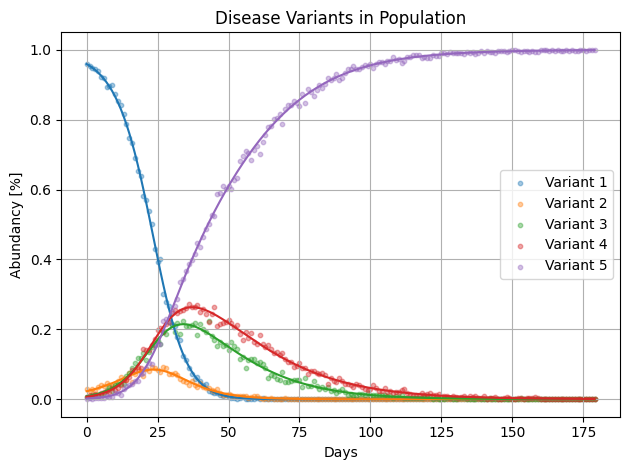

In [1018]:
plot_viral_composition_2(counts, composition_estimate)

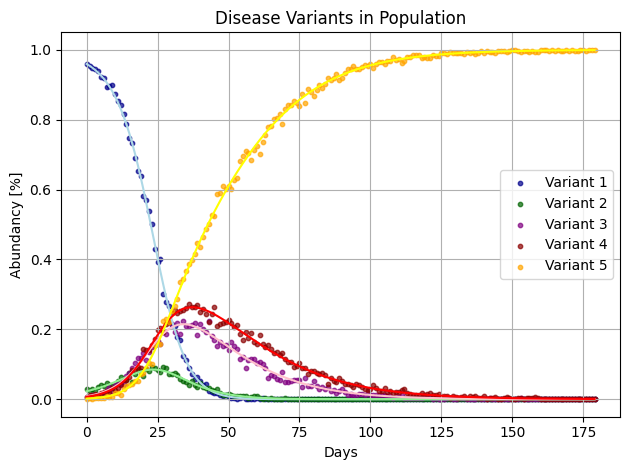

In [1019]:
colors_counts = ['darkblue', 'darkgreen', 'purple', 'darkred', 'orange']
colors_line = ['lightblue', 'lightgreen', 'pink', 'red', 'yellow']

plot_viral_composition(colors_counts, colors_line, counts, composition_estimate)

In [1020]:
result

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 84977.92587669306
        x: [ 0.000e+00  8.665e-02  1.532e-01  1.650e-01  2.123e-01
             0.000e+00 -3.732e+00 -4.694e+00 -4.912e+00 -6.247e+00]
      nit: 30
      jac: [ 1.600e-03 -1.507e-03  4.809e-04 -4.744e-04  3.365e-05
            -3.852e-05  1.905e-05 -1.079e-05]
 hess_inv: [[ 2.946e-06  1.214e-06 ... -2.495e-05 -2.524e-05]
            [ 1.214e-06  1.965e-06 ... -4.065e-05 -4.354e-05]
            ...
            [-2.495e-05 -4.065e-05 ...  1.469e-03  1.234e-03]
            [-2.524e-05 -4.354e-05 ...  1.234e-03  1.572e-03]]
     nfev: 125
     njev: 112

In [1021]:
#true_params = np.concatenate([growth_rates, np.log(init_freq)])
#growth_rate_range = (-0.05, 0.15)
#freq_range = (-8, 1)

def calculate_conf_intervals(result, true_params, growth_rate_range, freq_range, create_plot = True):

    z = 1.96    # 95% confidence interval
    standard_errors =  np.insert(z * np.sqrt(np.diag(result.hess_inv)), 0, 0.0)
    standard_errors =  np.insert(standard_errors, true_params.shape[0] // 2, 0.0)
    lower_bounds = result.x - standard_errors
    upper_bounds = result.x + standard_errors

    deviations = result.x - true_params
    abs_deviations = np.abs(deviations)
    estimated_correctly = abs_deviations <= standard_errors

    df = pd.DataFrame({
        'parameter_estimate': result.x,
        'true_parameter': true_params,
        'deviation': deviations,
        'abs_deviation': abs_deviations,
        'estimated_correctly': estimated_correctly,
        'standard_error': standard_errors,
        'ci_lower': lower_bounds,
        'ci_upper': upper_bounds,
        'n_variants': np.repeat(result.x.shape[0] // 2, result.x.shape[0]),
        'parameter_type': np.concatenate([np.repeat('growth_rate', result.x.shape[0] // 2), np.repeat('log_initial_freq', result.x.shape[0] // 2)])
    })

    if(create_plot):

        fig, axes = plt.subplots(1, 2, figsize=(16, 10))

        # Plot for s_i (first half)
        for i in range(len(result.x) // 2):
            color = "green" if lower_bounds[i] <= true_params[i] <= upper_bounds[i] else "red"
            axes[0].errorbar(i, result.x[i], yerr=standard_errors[i], fmt='o', capsize=5, color='black')
            axes[0].plot(i, true_params[i], 'x', color=color, markersize=10, label='True' if i == 0 else "")

        axes[0].set_title("Growth rate (s_i)")
        axes[0].set_ylim(growth_rate_range)
        axes[0].set_xlabel("Index")
        axes[0].set_ylabel("Estimated value")
        #axes[0].grid(True)

        # Plot for o_i (second half)
        for i in range(len(result.x) // 2):
            idx = i + len(result.x) // 2
            color = "green" if lower_bounds[idx] <= true_params[idx] <= upper_bounds[idx] else "red"
            axes[1].errorbar(i, result.x[idx], yerr=standard_errors[idx], fmt='o', capsize=5, color='black')
            axes[1].plot(i, true_params[idx], 'x', color=color, markersize=10, label='True' if i == 0 else "")

        axes[1].set_title("Log. initial frequencies (o_i)")
        axes[1].set_xlabel("Index")
        axes[1].set_ylim(freq_range)
        axes[1].set_ylabel("Estimated value")
        #axes[1].grid(True)

        legend_elements = [
                Line2D([0], [0], marker='o', color='black', linestyle='None', label='Parameter estimate'),
                Line2D([0], [0], marker='x', color='green', linestyle='None', label='True parameter inside CI', markersize=10),
                Line2D([0], [0], marker='x', color='red', linestyle='None', label='True parameter outside CI', markersize=10)
            ]
        fig.legend(handles=legend_elements, loc="upper right", ncol=1)

        plt.suptitle("95% Confidence Intervals for Parameters with Ground Truth", fontsize = 16)
        plt.show()

    return df

#calculate_conf_intervals(result, true_params, growth_rate_range, freq_range)

## Summary - Simulate data and estimate growth rates

In [1022]:
def predict_parameters(n_variants, n_days, n_samples, growth_rate_limit, create_plot = True):

    # randomly initiate growth rates and frequencies
    #growth_rates = calc_growth_rates(n_variants, (0,0), growth_rate_interval)
    growth_rates = calc_growth_rates_fixed_range(n_variants, growth_rate_limit)
    init_freq = calc_log_init_freq(n_variants)

    # generate count data
    freq_all_viral = calculate_frequencies(n_days, init_freq, growth_rates)
    counts = sample(freq_all_viral, n_samples)
    if create_plot:
        plot_variants(counts)

    # estimate parameters from count data
    initial_params = np.concatenate([np.repeat(0.1, n_variants - 1), np.repeat(-5, n_variants -1)])
    result, composition_estimate = calculate_viral_composition(initial_params, counts)

    if create_plot:
        plot_viral_composition_2(counts, composition_estimate)

    true_params = np.concatenate([growth_rates, init_freq])
    growth_rate_range = (-0.05, 0.05 * n_variants / 2)
    freq_range = (-8, 1)
    data_summary_df = calculate_conf_intervals(result, true_params, growth_rate_range, freq_range, create_plot = create_plot)

    return data_summary_df

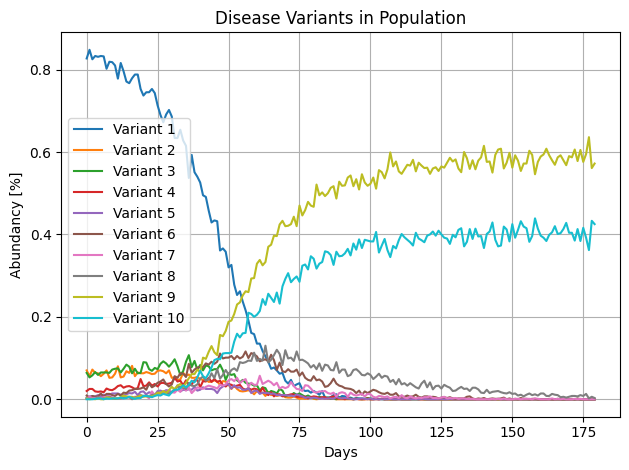

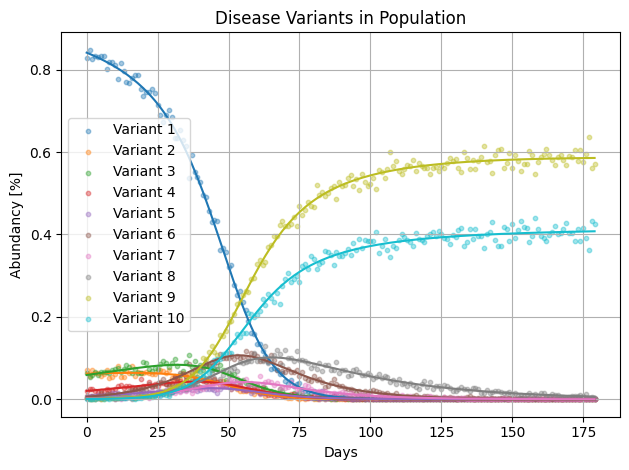

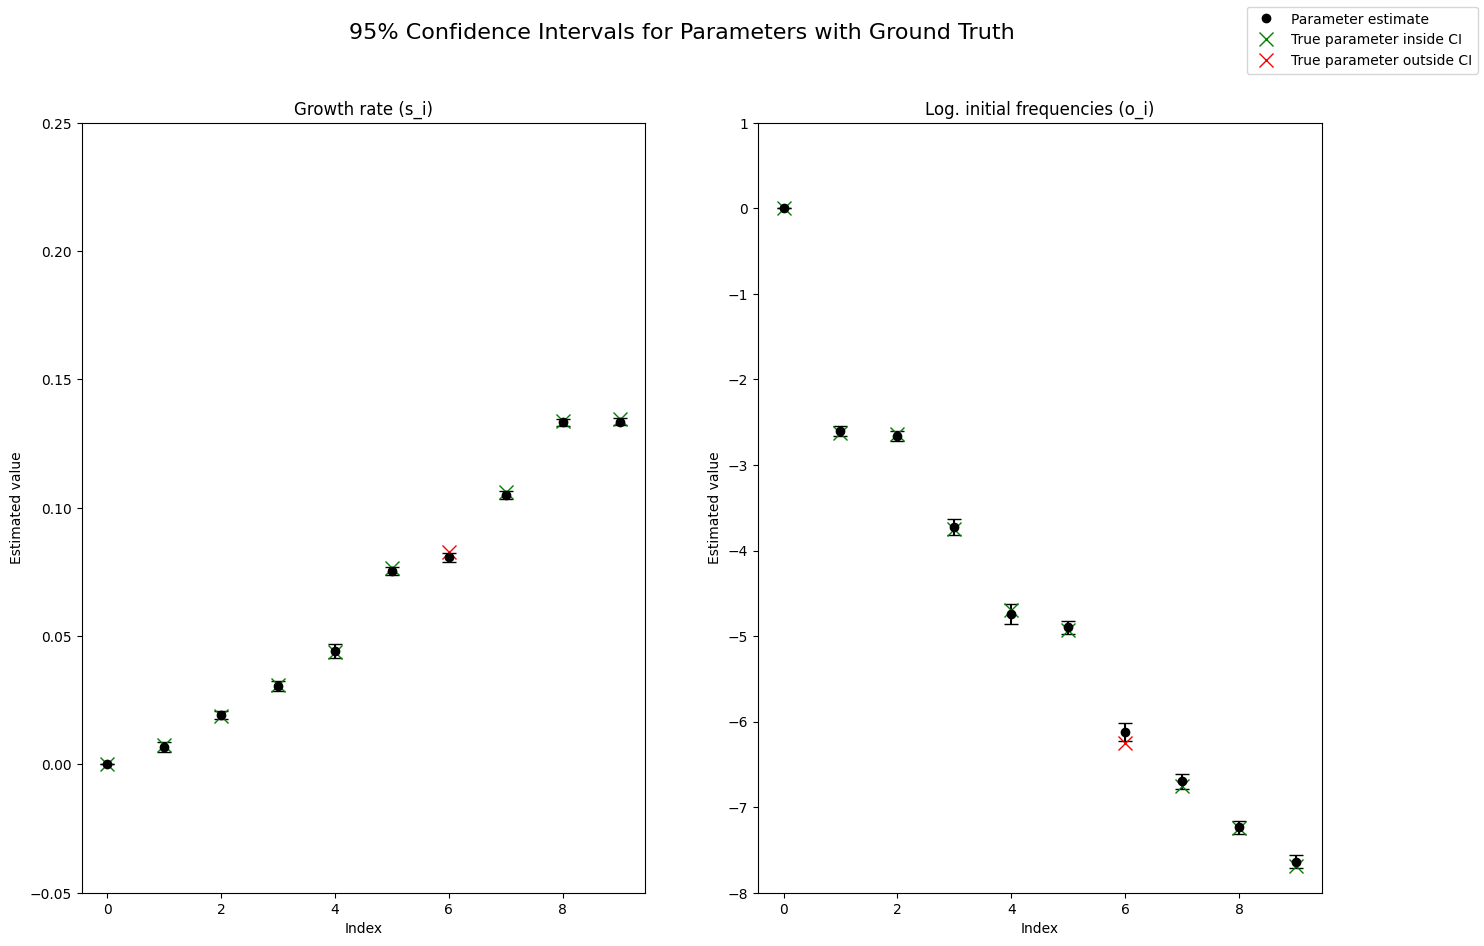

,parameter_estimate,true_parameter,deviation,abs_deviation,estimated_correctly,standard_error,ci_lower,ci_upper,n_variants,parameter_type
0,0.000000,0.000000,0.000000,0.000000,True,0.000000,0.000000,0.000000,10,growth_rate
1,0.006703,0.007720,-0.001017,0.001017,True,0.001976,0.004726,0.008679,10,growth_rate
2,0.019308,0.018838,0.000470,0.000470,True,0.001650,0.017658,0.020957,10,growth_rate
3,0.030528,0.031086,-0.000558,0.000558,True,0.002015,0.028513,0.032544,10,growth_rate
4,0.044014,0.043636,0.000378,0.000378,True,0.002723,0.041290,0.046737,10,growth_rate
5,0.075313,0.076624,-0.001311,0.001311,True,0.001442,0.073871,0.076756,10,growth_rate
6,0.080709,0.082620,-0.001911,0.001911,False,0.001786,0.078923,0.082494,10,growth_rate
7,0.105078,0.106222,-0.001144,0.001144,True,0.001492,0.103586,0.106570,10,growth_rate
8,0.133244,0.133942,-0.000698,0.000698,True,0.001404,0.131840,0.134647,10,growth_rate
9,0.133458,0.134444,-0.000986,0.000986,True,0.001404,0.132054,0.134862,10,growth_rate


In [1041]:
df = predict_parameters(n_variants = 10, n_days = 180, n_samples = 1000, growth_rate_limit = 0.15, create_plot = True)
df

/var/folders/l3/cr7pvqjn2054djbp5cf7qbd40000gn/T/ipykernel_7038/28336034.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


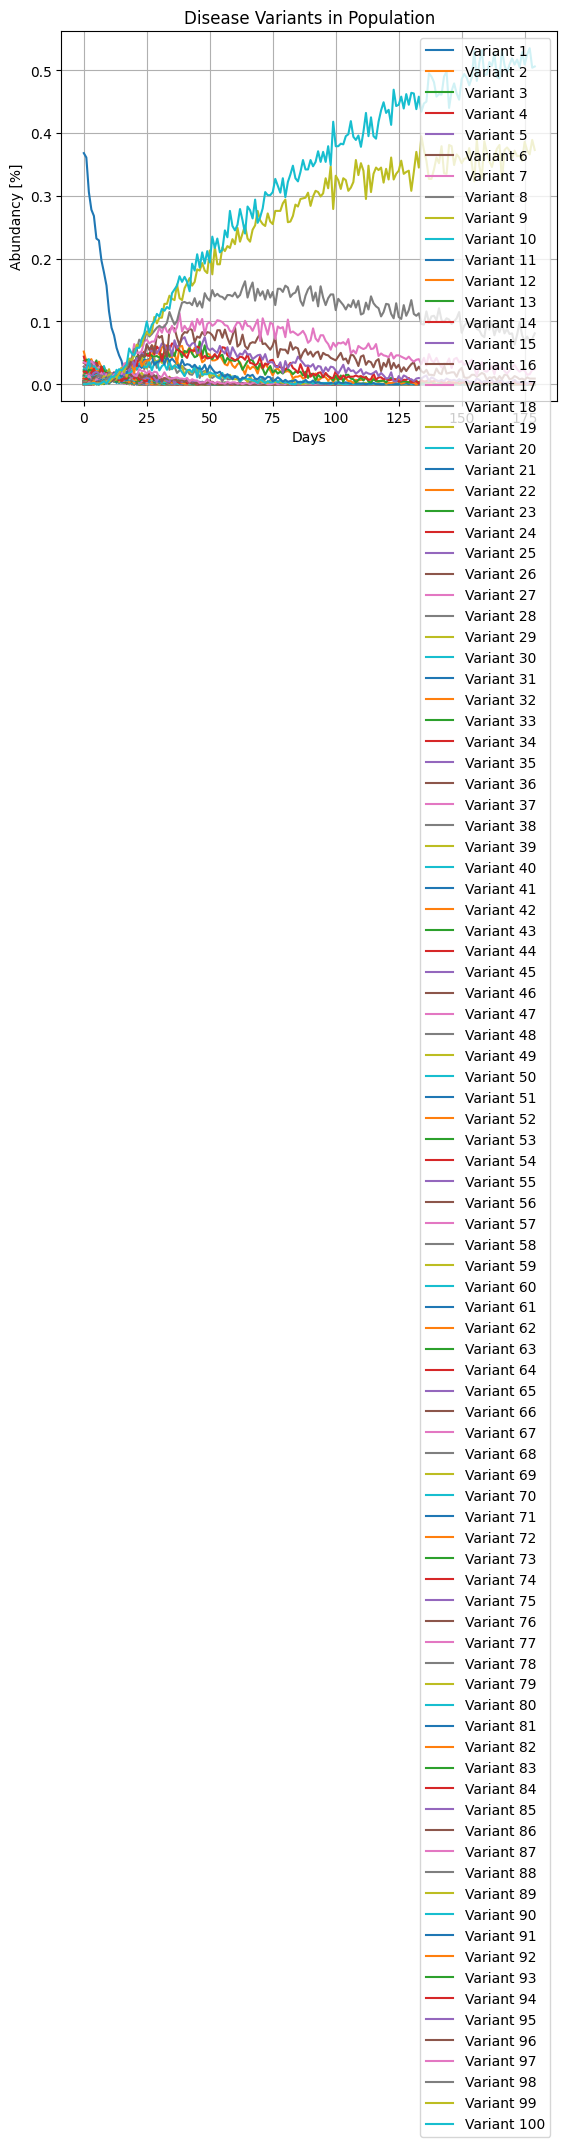

/var/folders/l3/cr7pvqjn2054djbp5cf7qbd40000gn/T/ipykernel_7038/2980149696.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


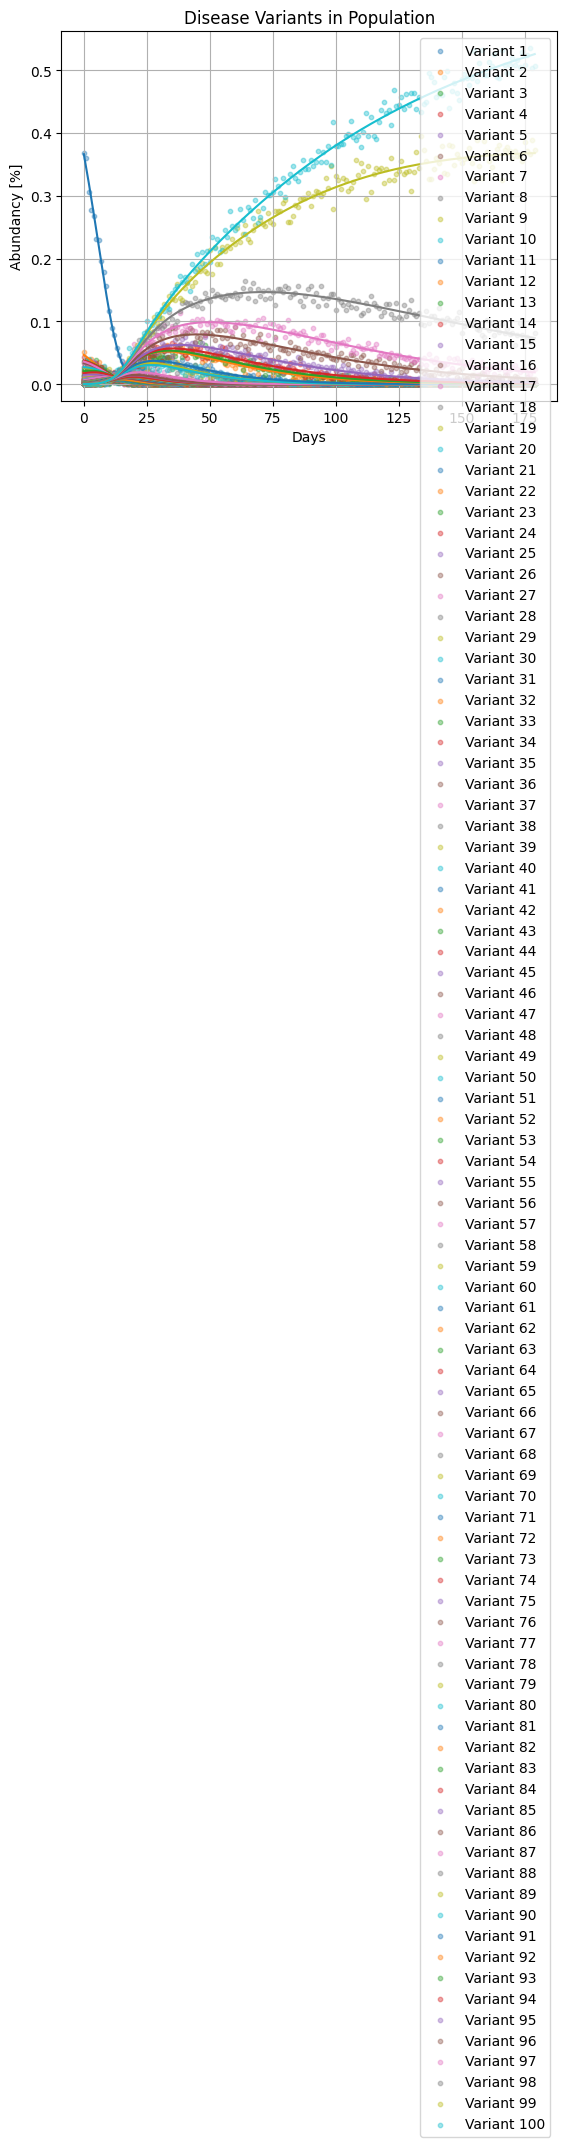

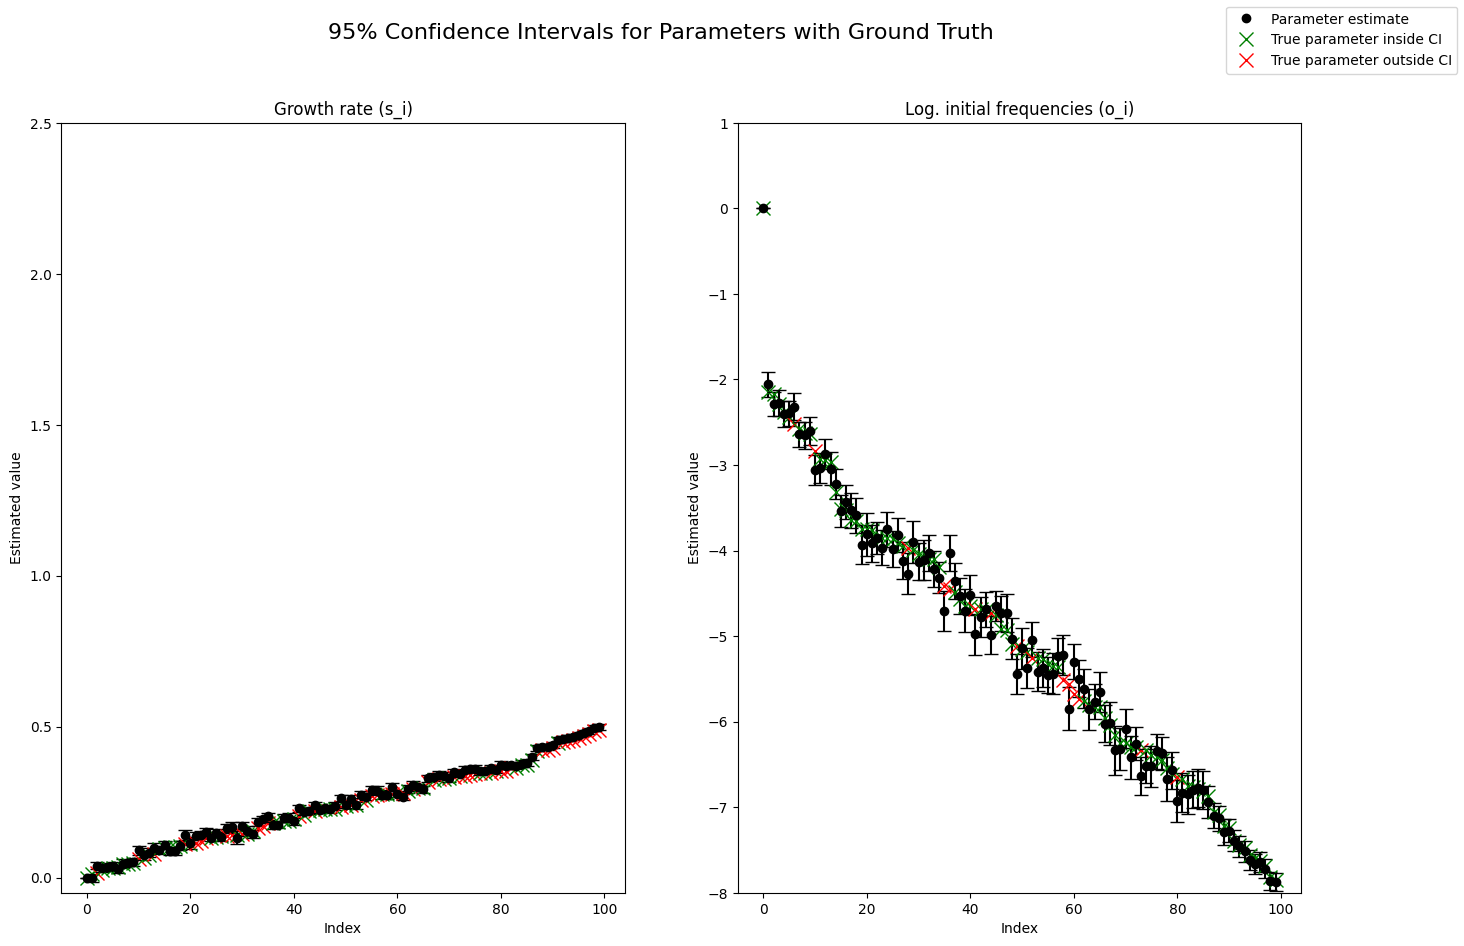

,parameter_estimate,true_parameter,deviation,abs_deviation,estimated_correctly,standard_error,ci_lower,ci_upper,n_variants,parameter_type
0,0.000000,0.000000,0.000000,0.000000,True,0.000000,0.000000,0.000000,100,growth_rate
1,-0.000642,0.011991,-0.012633,0.012633,True,0.013642,-0.014284,0.013000,100,growth_rate
2,0.040112,0.014938,0.025174,0.025174,False,0.012695,0.027418,0.052807,100,growth_rate
3,0.032316,0.025734,0.006582,0.006582,True,0.013528,0.018787,0.045844,100,growth_rate
4,0.034670,0.030764,0.003905,0.003905,True,0.013774,0.020896,0.048443,100,growth_rate
...,...,...,...,...,...,...,...,...,...,...
195,-7.668292,-7.598183,-0.070108,0.070108,True,0.115277,-7.783569,-7.553015,100,log_initial_freq
196,-7.641526,-7.630826,-0.010699,0.010699,True,0.112223,-7.753749,-7.529303,100,log_initial_freq
197,-7.720613,-7.691197,-0.029416,0.029416,True,0.109640,-7.830253,-7.610972,100,log_initial_freq
198,-7.859406,-7.820743,-0.038663,0.038663,True,0.107379,-7.966785,-7.752027,100,log_initial_freq


In [1096]:
predict_parameters(n_variants = 100, n_days = 180, n_samples = 1000, growth_rate_limit = 0.5, create_plot = True)


possibly add percentage of point out of confidence interval as text in plot

### Run algorithm for different numbers of variants

Naxt cell takes about 10 min to run.

In [1061]:
n_variants_vec = [5, 10, 20, 50, 100, 200, 500, 1000]
all_data = []

for n_var in n_variants_vec:
    data = predict_parameters(n_variants = n_var, n_days = 180, n_samples = 1000, growth_rate_limit = 0.5, create_plot=False)
    all_data.append(data)

predictions_df = pd.concat(all_data, ignore_index=True)

In [1063]:
predictions_df.to_csv("data/parameter_predictions.csv", index=False)

In [1087]:
growth_rate_df = predictions_df[predictions_df.parameter_type == 'growth_rate']
log_init_freq_df = predictions_df[predictions_df.parameter_type == 'log_initial_freq']

In [1089]:
# estimate percentage of correctly estimated growth rates and log inital freq
percentage_correct_gr = []
percentage_correct_lif = []

for n_var in n_variants_vec:
    correctly_estimated_gr = growth_rate_df[(growth_rate_df.n_variants == n_var) & (growth_rate_df.estimated_correctly)].shape[0]
    correctly_estimated_lif = log_init_freq_df[(log_init_freq_df.n_variants == n_var) & (log_init_freq_df.estimated_correctly)].shape[0]
    percentage_correct_gr.append(correctly_estimated_gr / n_var)
    percentage_correct_lif.append(correctly_estimated_lif / n_var)

print(percentage_correct_gr)
print(percentage_correct_lif)

[1.0, 1.0, 0.95, 0.82, 0.56, 0.875, 0.534, 0.853]
[1.0, 1.0, 1.0, 0.98, 0.85, 0.94, 0.878, 0.969]


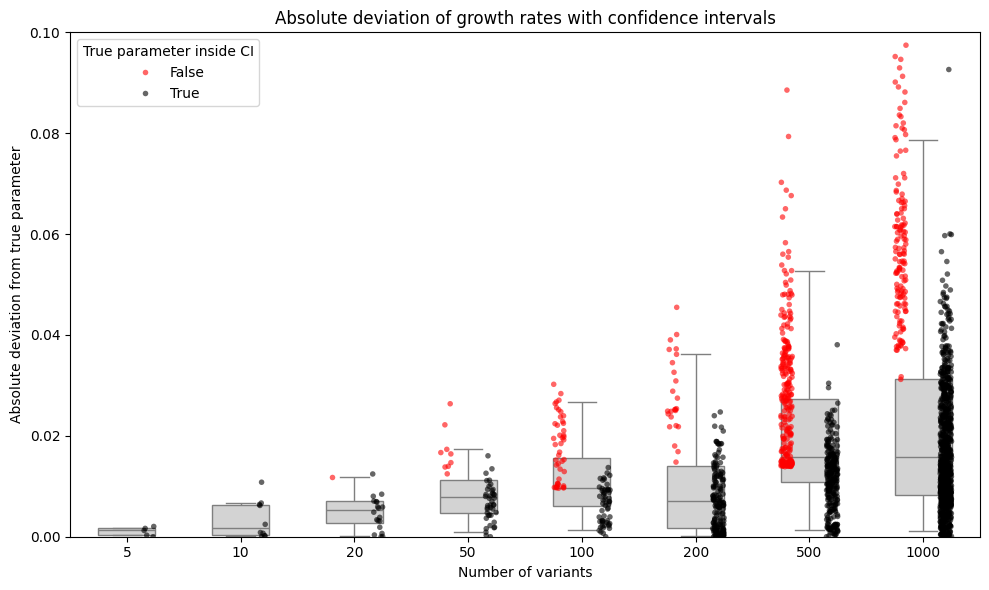

In [1091]:
plt.figure(figsize=(10, 6))

# Plot points first
palette = {True: 'black', False: 'red'}
sns.stripplot(data=growth_rate_df, x="n_variants", y="abs_deviation", hue="estimated_correctly",
              jitter=True, dodge=True, alpha=0.6, palette=palette, marker='o', size=4)

# Plot boxplot on top (Set whiskers to the 2.5% and 97.5% percentiles (like a 95% CI))
sns.boxplot(data=growth_rate_df, x="n_variants", y="abs_deviation", whis=[2.5, 97.5], 
            color='lightgray', width=0.5, fliersize=0)

# Horizontal line at zero
#plt.axhline(0, color='gray', linestyle='--')

# Axis labels and title
plt.xlabel("Number of variants")
plt.ylabel("Absolute deviation from true parameter")
plt.title("Absolute deviation of growth rates with confidence intervals")

plt.ylim(0, 0.1) # for log-scale

# Handle legend properly (avoid duplicate entries due to overlapping plots)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title="True parameter inside CI")

plt.tight_layout()
plt.show()


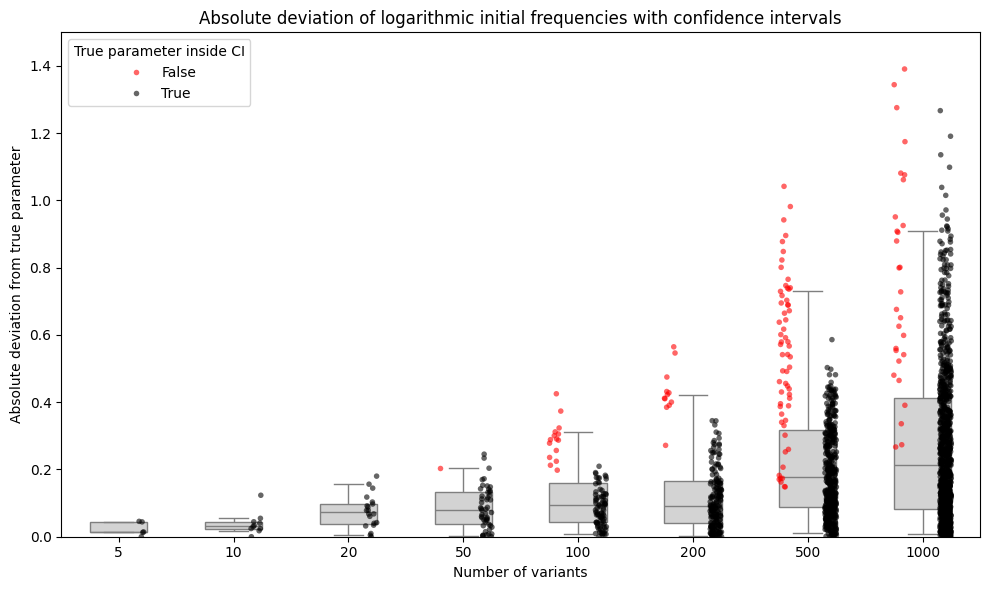

In [1094]:
plt.figure(figsize=(10, 6))

# Plot points first
palette = {True: 'black', False: 'red'}
sns.stripplot(data=log_init_freq_df, x="n_variants", y="abs_deviation", hue="estimated_correctly",
              jitter=True, dodge=True, alpha=0.6, palette=palette, marker='o', size=4)

# Plot boxplot on top (Set whiskers to the 2.5% and 97.5% percentiles (like a 95% CI))
sns.boxplot(data=log_init_freq_df, x="n_variants", y="abs_deviation", whis=[2.5, 97.5], 
            color='lightgray', width=0.5, fliersize=0)

# Horizontal line at zero
#plt.axhline(0, color='gray', linestyle='--')

# Axis labels and title
plt.xlabel("Number of variants")
plt.ylabel("Absolute deviation from true parameter")
plt.title("Absolute deviation of logarithmic initial frequencies with confidence intervals")

plt.ylim(0, 1.5) # for log-scale

# Handle legend properly (avoid duplicate entries due to overlapping plots)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title="True parameter inside CI")

plt.tight_layout()
plt.show()


In [ ]:
def set_parameters(n_variants, n_days, delta_gr_range, rate, freq_entering_variants, s_0 = 0, o_0 = 0):

    s_vec = np.zeros(n_variants)
    o_vec = np.zeros(n_variants)

    s_vec[0] = s_0
    o_vec[0] = o_0

    var_count = 1

    for t in range(1, n_days):

        if (var_count == n_variants):
            break

        n_new_variants = min(np.random.poisson(rate), n_variants - var_count)
        
        if (n_new_variants > 0):
            
            logits = s_vec[0:var_count] * t + o_vec[0:var_count]
            max_l = np.max(logits)
            log_sum_exp = np.exp(logits - max_l)
            avg_s = np.dot(s_vec[0:var_count], log_sum_exp / np.sum(log_sum_exp))

            s_vec[var_count:var_count + n_new_variants] = avg_s + np.random.uniform(0, delta_gr_range, n_new_variants)
            o_vec[var_count:var_count + n_new_variants] = np.log(freq_entering_variants/(1 - freq_entering_variants)) +  np.log(np.sum(log_sum_exp)) + max_l - s_vec[var_count:var_count + n_new_variants] * t

            var_count += n_new_variants

    if(n_variants > var_count):
        n_variants = var_count
        s_vec = s_vec[0:n_variants]
        o_vec = o_vec[0:n_variants]

    return s_vec, o_vec

In [ ]:
def calculate_distance_matrix(counts):

    variant_normalized_counts = counts / np.sum(counts, axis = 0)
    t_peaks = np.sum(variant_normalized_counts * np.arange(counts.shape[0])[:, np.newaxis], axis = 0)
    
    sorted_t_peaks = np.sort(t_peaks)
    abs_dist_matrix = np.abs(sorted_t_peaks[:, np.newaxis] - sorted_t_peaks[np.newaxis, :])

    return abs_dist_matrix